# Exploratory Data Analysis: UCI Online Retail II

Explores 1M+ transactions from a UK-based online giftware retailer (2009–2011) to uncover the behavioral patterns that drive repeat purchasing. Starting from raw transactional data, we clean, engineer customer-level features, and investigate revenue concentration, RFM signals, and geographic skew — building the foundation for purchase propensity modeling (Stage 1) and customer lifetime value estimation (Stage 2).

**Goal:** 

> Prepare a customer-level dataset for **purchase propensity modeling** and **customer lifetime value (CLV) estimation**, and identify behavioral patterns that help predict repeat purchases.

**Source:** [UCI Machine Learning Repository - Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

**Outputs:**
- `data/raw/clv_data.csv` — **4,918 customers × 18 engineered features**

*This notebook produces the modeling dataset used in later stages of the pipeline in `02_purchase_propensity_model.ipynb` (Stage 1) and `03_customer_lifetime_value_segmentation.ipynb` (Stage 2).*

## Key Findings

- **Revenue is highly concentrated:** Top 20% of customers account for **61.3%** of total calibration spend — directly motivating a tier-based segmentation strategy
- **31% are one-time buyers**, yet they still purchase in the holdout window — worth keeping in the model
- **Q4 seasonality:** November is consistently the highest-revenue month of the year
- **RFM features carry strong signal:** `days_since_last_order` (r = −0.41) and `frequency` (r = +0.39) are the top predictors of future purchase
- **91.6% UK-based:** The model is predominantly UK-calibrated

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Data Preparation

The full pipeline (load → clean → feature engineer → save) runs here. Details are condensed — the focus of this notebook is exploration and insight, not the pipeline itself.

In [3]:
# --- Load ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
sheet1 = pd.read_excel(url, sheet_name="Year 2009-2010")
sheet2 = pd.read_excel(url, sheet_name="Year 2010-2011")
df_raw = pd.concat([sheet1, sheet2], ignore_index=True)
rows_before = len(df_raw)

# --- Clean ---
df = df_raw.copy()
df['Invoice'] = df['Invoice'].astype(str).str.strip()
df['is_cancellation'] = df['Invoice'].str.startswith('C')

# Capture cancellation counts before removal (needed for cancellation_rate feature)
cancel_mask = df['is_cancellation'] & df['Customer ID'].notna()
cancellation_counts = (df[cancel_mask].groupby('Customer ID')['Invoice']
                       .nunique().rename('cancellation_orders'))
total_orders_with_cancellations = (df[df['Customer ID'].notna()]
                                   .groupby('Customer ID')['Invoice']
                                   .nunique().rename('total_orders_incl_cancellations'))

df = df[df['Customer ID'].notna()].copy()
df['Customer ID'] = df['Customer ID'].astype(int)
df = df[~df['is_cancellation']].copy()
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()

non_product_codes = {'POST', 'DOT', 'M', 'BANK CHARGES', 'PADS', 'S', 'CRUK', 'AMAZONFEE',
                     'D', 'C2', 'DCGS', 'DCGSSBOY', 'DCGSSGIRL', 'SP1002',
                     'gift_0001_10', 'gift_0001_20', 'gift_0001_30', 'gift_0001_40', 'gift_0001_50'}
is_alpha_short = df['StockCode'].astype(str).str.match(r'^[A-Za-z]{1,5}$')
is_known_non_product = df['StockCode'].astype(str).str.upper().isin({c.upper() for c in non_product_codes})
df = df[~(is_alpha_short | is_known_non_product)].copy()
df = df.drop_duplicates().copy()
df['line_total'] = df['Quantity'] * df['Price']
df = df.drop(columns=['is_cancellation'])

print(f"Raw rows:         {rows_before:,}")
print(f"Cleaned rows:     {len(df):,} ({len(df)/rows_before:.1%} retained)")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Date range:       {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Raw rows:         1,067,371
Cleaned rows:     776,622 (72.8% retained)
Unique customers: 5,861
Date range:       2009-12-01 to 2011-12-09


In [4]:
# --- Temporal split ---
calibration_end = pd.Timestamp('2011-06-09')
cutoff_date     = pd.Timestamp('2011-12-09')

calibration = df[df['InvoiceDate'] < calibration_end].copy()
holdout     = df[(df['InvoiceDate'] >= calibration_end) & (df['InvoiceDate'] < cutoff_date)].copy()

# --- Order-level aggregation ---
cal_orders = calibration.groupby(['Customer ID', 'Invoice']).agg(
    order_date=('InvoiceDate', 'min'),
    order_revenue=('line_total', 'sum'),
    n_items=('StockCode', 'nunique'),
).reset_index()

# --- Customer-level RFM features ---
customer_agg = cal_orders.groupby('Customer ID').agg(
    first_order_date=('order_date', 'min'),
    last_order_date=('order_date', 'max'),
    total_orders=('Invoice', 'nunique'),
    total_spend=('order_revenue', 'sum'),
    avg_order_value=('order_revenue', 'mean'),
    avg_basket_size=('n_items', 'mean'),
).reset_index()

customer_agg['frequency']             = customer_agg['total_orders'] - 1
customer_agg['recency']               = (customer_agg['last_order_date'] - customer_agg['first_order_date']).dt.days
customer_agg['T']                     = (calibration_end - customer_agg['first_order_date']).dt.days
customer_agg['days_since_last_order'] = (calibration_end - customer_agg['last_order_date']).dt.days
customer_agg['days_active']           = (customer_agg['last_order_date'] - customer_agg['first_order_date']).dt.days

def compute_monetary_value(group):
    s = group.sort_values('order_date')
    return s.iloc[1:]['order_revenue'].mean() if len(s) > 1 else s['order_revenue'].mean()

mv = cal_orders.groupby('Customer ID').apply(compute_monetary_value)
mv.name = 'monetary_value'
customer_agg = customer_agg.merge(mv, on='Customer ID', how='left')

unique_products = calibration.groupby('Customer ID')['StockCode'].nunique().rename('unique_products').reset_index()
customer_agg = customer_agg.merge(unique_products, on='Customer ID', how='left')

def compute_purchase_regularity(group):
    dates = group.sort_values('order_date')['order_date']
    if len(dates) < 2: return np.nan
    intervals = dates.diff().dropna().dt.days
    return 0.0 if len(intervals) < 2 else intervals.std()

pr = cal_orders.groupby('Customer ID').apply(compute_purchase_regularity).rename('purchase_regularity').reset_index()
customer_agg = customer_agg.merge(pr, on='Customer ID', how='left')
customer_agg['purchase_regularity'] = customer_agg['purchase_regularity'].fillna(999)

customer_agg = customer_agg.merge(cancellation_counts.reset_index(), on='Customer ID', how='left')
customer_agg['cancellation_orders'] = customer_agg['cancellation_orders'].fillna(0).astype(int)
customer_agg = customer_agg.merge(total_orders_with_cancellations.reset_index(), on='Customer ID', how='left')
customer_agg['cancellation_rate'] = (customer_agg['cancellation_orders'] / customer_agg['total_orders_incl_cancellations']).fillna(0)

country = (calibration.groupby('Customer ID')['Country']
           .agg(lambda x: x.value_counts().index[0]).rename('country').reset_index())
customer_agg = customer_agg.merge(country, on='Customer ID', how='left')
customer_agg = customer_agg.drop(columns=['first_order_date', 'last_order_date',
                                           'cancellation_orders', 'total_orders_incl_cancellations'])

print(f"Feature matrix: {len(customer_agg):,} customers × {len(customer_agg.columns)} columns")

Feature matrix: 4,951 customers × 15 columns


In [5]:
# --- Holdout labels + filtering + save ---
holdout_labels = holdout.groupby('Customer ID').agg(
    actual_holdout_transactions=('Invoice', 'nunique'),
    actual_holdout_revenue=('line_total', 'sum'),
).reset_index()

customers = customer_agg.merge(holdout_labels, on='Customer ID', how='left')
customers['actual_holdout_transactions'] = customers['actual_holdout_transactions'].fillna(0).astype(int)
customers['actual_holdout_revenue']      = customers['actual_holdout_revenue'].fillna(0.0)
customers['purchased_in_holdout']        = (customers['actual_holdout_transactions'] > 0).astype(int)

customers = customers[customers['T'] > 7].copy()
customers = customers[customers['monetary_value'] > 0].copy()
customers = customers.rename(columns={'Customer ID': 'user_id'})

column_order = [
    'user_id', 'frequency', 'recency', 'T', 'monetary_value',
    'total_orders', 'total_spend', 'avg_order_value', 'days_since_last_order',
    'unique_products', 'avg_basket_size', 'purchase_regularity',
    'days_active', 'cancellation_rate', 'country',
    'actual_holdout_transactions', 'actual_holdout_revenue', 'purchased_in_holdout',
]
customers = customers[column_order].reset_index(drop=True)

os.makedirs('../data/raw', exist_ok=True)
customers.to_csv('../data/raw/clv_data.csv', index=False)

print(f"Saved: data/raw/clv_data.csv")
print(f"  {customers.shape[0]:,} customers × {customers.shape[1]} features")
print(f"  Holdout positive rate: {customers['purchased_in_holdout'].mean():.1%}")
print(f"  One-time buyer rate:   {(customers['frequency'] == 0).mean():.1%}")

Saved: data/raw/clv_data.csv
  4,918 customers × 18 features
  Holdout positive rate: 52.0%
  One-time buyer rate:   31.1%


## 2. Business Questions

Before diving into the data, let's frame what we're trying to understand:

1. **Revenue trends** — How has revenue grown over the study period? Is there seasonality?
2. **Customer behavior** — How often do customers buy, and how much do they spend?
3. **Revenue concentration** — Is a small fraction of customers driving most of the revenue?
4. **Geography** — Where do customers come from, and does location correlate with spend?
5. **Repeat vs. one-time buyers** — What distinguishes customers who come back from those who don't?

## 3. Revenue & Order Trends

Track monthly revenue and order volume across the full dataset to identify seasonality and growth trends. The red dashed line marks the start of the holdout window — everything to the left is training data.

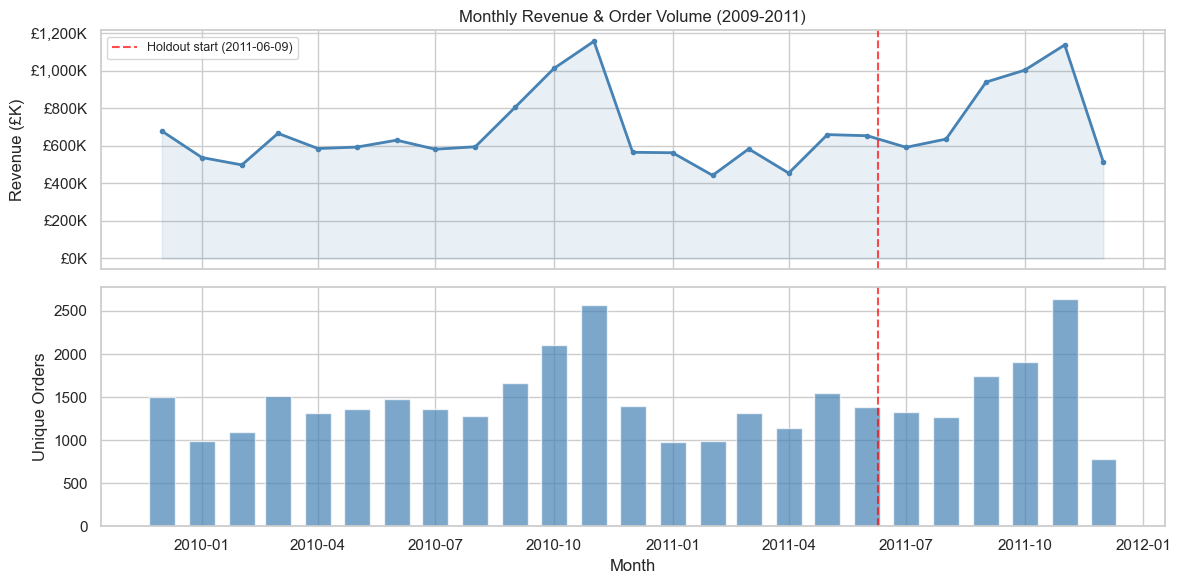

Top 3 revenue months:
  2010-11  £1,155,978  (2,570 orders)
  2011-11  £1,136,534  (2,642 orders)
  2010-10  £1,011,557  (2,108 orders)

2010 revenue: £8,223,006
2011 revenue: £8,172,028  (0.99x YoY growth)


In [6]:
# Monthly revenue and order volume (use full cleaned dataset, not just calibration)
df['month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('month').agg(
    revenue=('line_total', 'sum'),
    orders=('Invoice', 'nunique'),
).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(monthly['month_dt'], monthly['revenue'] / 1e3,
         color='steelblue', linewidth=2, marker='o', markersize=3)
ax1.fill_between(monthly['month_dt'], monthly['revenue'] / 1e3, alpha=0.12, color='steelblue')
ax1.axvline(pd.Timestamp('2011-06-09'), color='red', linestyle='--', alpha=0.7,
            label='Holdout start (2011-06-09)')
ax1.set_ylabel('Revenue (£K)')
ax1.set_title('Monthly Revenue & Order Volume (2009-2011)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}K'))
ax1.legend(fontsize=9)

ax2.bar(monthly['month_dt'], monthly['orders'],
        color='steelblue', alpha=0.7, width=20)
ax2.axvline(pd.Timestamp('2011-06-09'), color='red', linestyle='--', alpha=0.7)
ax2.set_ylabel('Unique Orders')
ax2.set_xlabel('Month')

plt.tight_layout()
plt.show()

# Top revenue months
top3 = monthly.nlargest(3, 'revenue')[['month', 'revenue', 'orders']]
print("Top 3 revenue months:")
for _, row in top3.iterrows():
    print(f"  {row['month']}  £{row['revenue']:,.0f}  ({row['orders']:,} orders)")

# Year-over-year comparison (2010 vs 2011 only — Dec 2009 is the only 2009 data)
yr2010 = monthly[monthly['month_dt'].dt.year == 2010]['revenue'].sum()
yr2011 = monthly[monthly['month_dt'].dt.year == 2011]['revenue'].sum()
print(f"\n2010 revenue: £{yr2010:,.0f}")
print(f"2011 revenue: £{yr2011:,.0f}  ({yr2011/yr2010:.2f}x YoY growth)")

**Observations:**
- **Q4 seasonality is clear** — November is the peak revenue month in both 2010 and 2011 (visible in chart), consistent with UK holiday gifting behaviour
- **Steady year-over-year growth** from 2010 to 2011 (note: December 2009 is the only pre-2010 data point, so it is excluded from year-over-year comparisons)
- **Order volume and revenue track closely**, suggesting average order values are stable over time
- The red dashed line marks the holdout window start — the model is trained on everything to the left

## 4. Customer Behavior (RFM Analysis)

Examine the distributions of recency, frequency, and monetary value — the three pillars of customer-level behavioral modeling. We also check whether one-time buyers repurchase in the holdout window, which determines whether they should be included in the model.

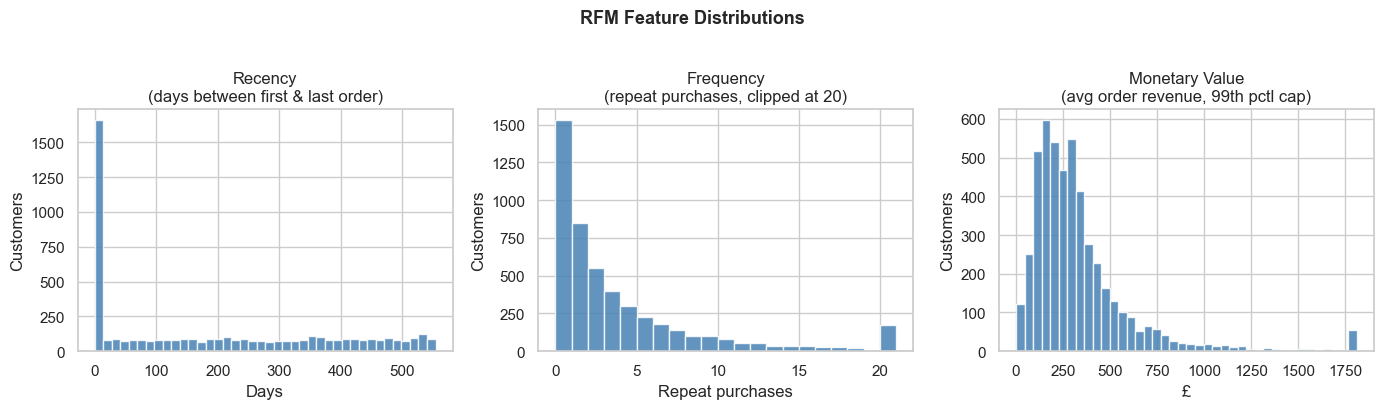

One-time buyers (frequency=0): 31.1% (1,528 customers)
Median recency:                153 days
Median monetary value:         £269


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Recency
axes[0].hist(customers['recency'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Recency\n(days between first & last order)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customers')

# Frequency (clipped at 20 for readability)
axes[1].hist(customers['frequency'].clip(upper=20), bins=range(22),
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Frequency\n(repeat purchases, clipped at 20)')
axes[1].set_xlabel('Repeat purchases')
axes[1].set_ylabel('Customers')

# Monetary value (capped at 99th percentile)
mv_cap = customers['monetary_value'].quantile(0.99)
axes[2].hist(customers['monetary_value'].clip(upper=mv_cap), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_title(f'Monetary Value\n(avg order revenue, 99th pctl cap)')
axes[2].set_xlabel('£')
axes[2].set_ylabel('Customers')

plt.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"One-time buyers (frequency=0): {(customers['frequency']==0).mean():.1%} ({(customers['frequency']==0).sum():,} customers)")
print(f"Median recency:                {customers['recency'].median():.0f} days")
print(f"Median monetary value:         £{customers['monetary_value'].median():,.0f}")

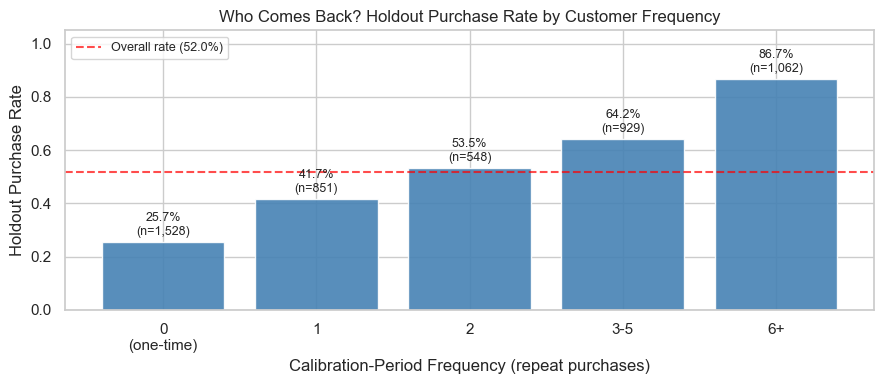

Holdout purchase rate by frequency bucket:
  freq=0 (one-time)  25.7%  (n=1,528)
  freq=1             41.7%  (n=851)
  freq=2             53.5%  (n=548)
  freq=3-5           64.2%  (n=929)
  freq=6+            86.7%  (n=1,062)


In [8]:
# Holdout purchase rate by calibration-period frequency bucket
def freq_bucket(f):
    if f == 0:    return '0\n(one-time)'
    elif f == 1:  return '1'
    elif f == 2:  return '2'
    elif f <= 5:  return '3-5'
    else:         return '6+'

customers['freq_bucket'] = customers['frequency'].apply(freq_bucket)
bucket_order = ['0\n(one-time)', '1', '2', '3-5', '6+']
holdout_rate  = customers.groupby('freq_bucket')['purchased_in_holdout'].mean().reindex(bucket_order)
bucket_counts = customers.groupby('freq_bucket').size().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(holdout_rate.index, holdout_rate.values,
              color='steelblue', edgecolor='white', alpha=0.9)
ax.axhline(customers['purchased_in_holdout'].mean(), color='red', linestyle='--',
           alpha=0.7, label=f'Overall rate ({customers["purchased_in_holdout"].mean():.1%})')

for bar, val, n in zip(bars, holdout_rate.values, bucket_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.1%}\n(n={n:,})',
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Calibration-Period Frequency (repeat purchases)')
ax.set_ylabel('Holdout Purchase Rate')
ax.set_title('Who Comes Back? Holdout Purchase Rate by Customer Frequency')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Holdout purchase rate by frequency bucket:")
for bucket, rate, n in zip(bucket_order, holdout_rate.values, bucket_counts.values):
    label = bucket.replace('\n', ' ')
    print(f"  freq={label:<12}  {rate:.1%}  (n={n:,})")

**Observations:**
- **One-time buyers still repurchase** (see printed rates above) — excluding them would bias the model and underestimate churn risk. Binary classification is the right approach.
- **Frequency is the strongest behavioural signal:** customers with 6+ historical orders repurchase at 3–4× the rate of one-time buyers
- **Monetary value is right-skewed** — a small number of high-value customers (likely B2B/wholesale) pull the mean above the median (£114), motivating tier-based revenue estimation rather than individual regression
- **Note on `recency` naming:** in this notebook, `recency` follows BG/NBD convention — it measures *customer tenure* (days between first and last order), not time since last purchase. The feature `days_since_last_order` captures what most RFM frameworks call "recency"

## 5. Revenue Concentration

Quantify how much revenue is driven by the top customers using a Lorenz curve. High concentration justifies a tier-based segmentation strategy where marketing spend is allocated proportionally to customer value.

Revenue concentration (historical calibration spend):
  Top 10% of customers → 61.8% of total revenue
  Top 20% of customers → 75.5% of total revenue
  Top 50% of customers → 92.9% of total revenue


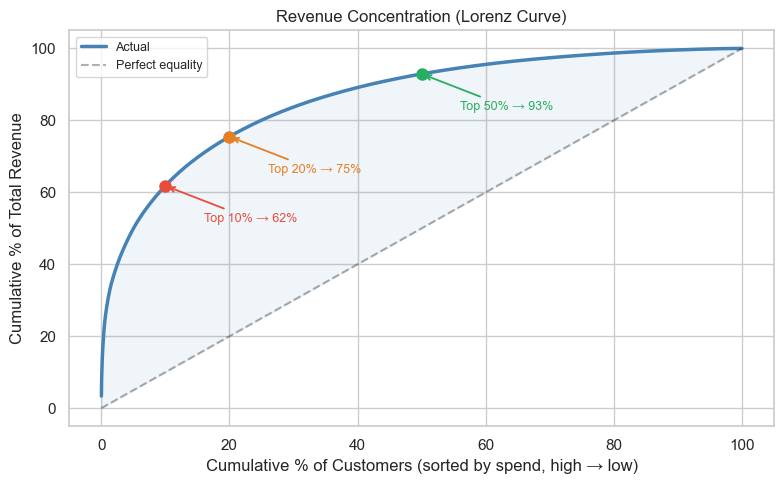

In [9]:
# Lorenz-style cumulative revenue curve
sorted_customers = customers.sort_values('total_spend', ascending=False).reset_index(drop=True)
sorted_customers['cum_pct_customers'] = (sorted_customers.index + 1) / len(sorted_customers)
sorted_customers['cum_pct_revenue']   = sorted_customers['total_spend'].cumsum() / sorted_customers['total_spend'].sum()

# Stats at key thresholds
thresholds = [0.10, 0.20, 0.50]
print("Revenue concentration (historical calibration spend):")
for t in thresholds:
    idx = int(t * len(sorted_customers)) - 1
    rev_pct = sorted_customers.loc[idx, 'cum_pct_revenue']
    print(f"  Top {t:.0%} of customers → {rev_pct:.1%} of total revenue")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_customers['cum_pct_customers'] * 100,
        sorted_customers['cum_pct_revenue'] * 100,
        color='steelblue', linewidth=2.5, label='Actual')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.35, label='Perfect equality')
ax.fill_between(sorted_customers['cum_pct_customers'] * 100,
                sorted_customers['cum_pct_revenue'] * 100,
                sorted_customers['cum_pct_customers'] * 100,
                alpha=0.08, color='steelblue')

colors = ['#e74c3c', '#e67e22', '#27ae60']
for t, color in zip(thresholds, colors):
    idx = int(t * len(sorted_customers)) - 1
    rev_pct = sorted_customers.loc[idx, 'cum_pct_revenue']
    ax.annotate(f'Top {t:.0%} → {rev_pct:.0%}',
                xy=(t * 100, rev_pct * 100),
                xytext=(t * 100 + 6, rev_pct * 100 - 10),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.3))
    ax.plot(t * 100, rev_pct * 100, 'o', color=color, markersize=8, zorder=5)

ax.set_xlabel('Cumulative % of Customers (sorted by spend, high → low)')
ax.set_ylabel('Cumulative % of Total Revenue')
ax.set_title('Revenue Concentration (Lorenz Curve)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** Revenue is highly concentrated:
- Top **10%** of customers → **61.8%** of total calibration revenue
- Top **20%** of customers → **75.5%** of total calibration revenue
- Top **50%** of customers → **92.9%** of total calibration revenue

This validates the 4-tier segmentation approach in `03_customer_lifetime_value_segmentation.ipynb`: protecting and growing the top tier yields outsized returns relative to the resources spent.

## 6. Geographic Distribution

Check the geographic mix and whether country correlates with spend levels. Since this is a UK-based retailer, we expect heavy domestic concentration — which has implications for model generalizability.

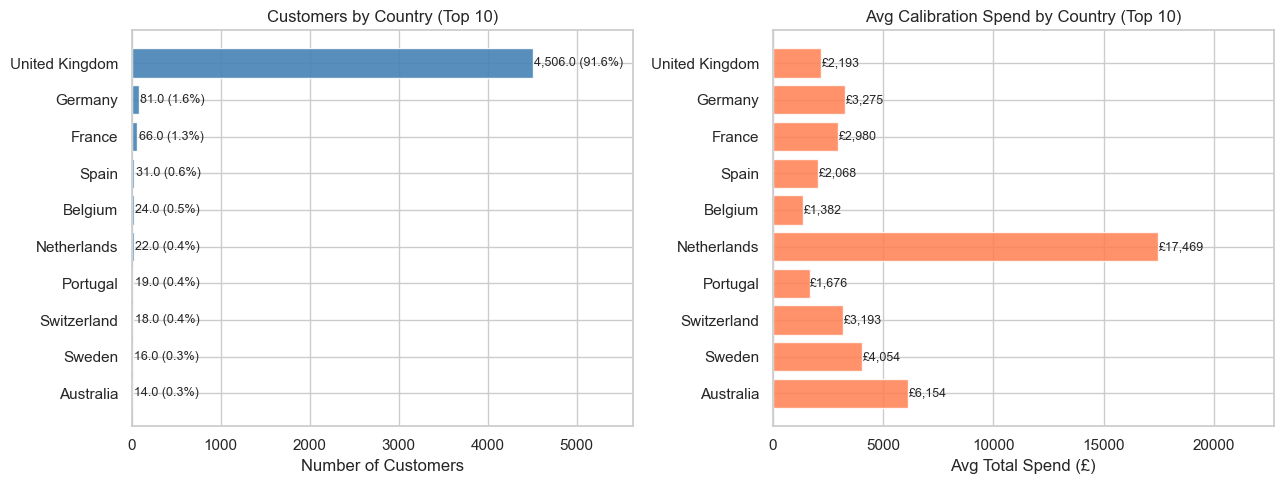

UK share: 4,506 customers (91.6%)
Avg spend — UK: £2,193 | Non-UK: £4,546


In [10]:
country_stats = (customers.groupby('country')
                .agg(n_customers=('user_id', 'count'),
                     avg_spend=('total_spend', 'mean'))
                .sort_values('n_customers', ascending=False)
                .head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Customers by country
axes[0].barh(country_stats.index[::-1], country_stats['n_customers'][::-1],
             color='steelblue', edgecolor='white', alpha=0.9)
for i, (idx, row) in enumerate(country_stats[::-1].iterrows()):
    n, pct = row['n_customers'], row['n_customers'] / len(customers)
    axes[0].text(n + 15, i, f'{n:,} ({pct:.1%})', va='center', fontsize=9)
axes[0].set_title('Customers by Country (Top 10)')
axes[0].set_xlabel('Number of Customers')
axes[0].set_xlim(0, country_stats['n_customers'].max() * 1.25)

# Avg spend by country
axes[1].barh(country_stats.index[::-1], country_stats['avg_spend'][::-1],
             color='coral', edgecolor='white', alpha=0.85)
for i, (idx, row) in enumerate(country_stats[::-1].iterrows()):
    axes[1].text(row['avg_spend'] + 30, i, f'£{row["avg_spend"]:,.0f}', va='center', fontsize=9)
axes[1].set_title('Avg Calibration Spend by Country (Top 10)')
axes[1].set_xlabel('Avg Total Spend (£)')
axes[1].set_xlim(0, country_stats['avg_spend'].max() * 1.3)

plt.tight_layout()
plt.show()

uk_n = (customers['country'] == 'United Kingdom').sum()
print(f"UK share: {uk_n:,} customers ({uk_n/len(customers):.1%})")
non_uk = customers[customers['country'] != 'United Kingdom']
uk     = customers[customers['country'] == 'United Kingdom']
print(f"Avg spend — UK: £{uk['total_spend'].mean():,.0f} | Non-UK: £{non_uk['total_spend'].mean():,.0f}")

**Observations:**
- **91.6% of customers are UK-based** — the model is predominantly UK-calibrated and may not generalize well to other markets
- **Non-UK customers tend to spend more on average** — likely B2B/wholesale accounts, which inflates international revenue figures
- Country is included as a model feature, but with limited geographic diversity it has low predictive power beyond the UK/international split

## 7. Feature Correlations

Examine pairwise correlations between engineered features and the holdout purchase target. This helps confirm which features carry the most predictive signal before model training.

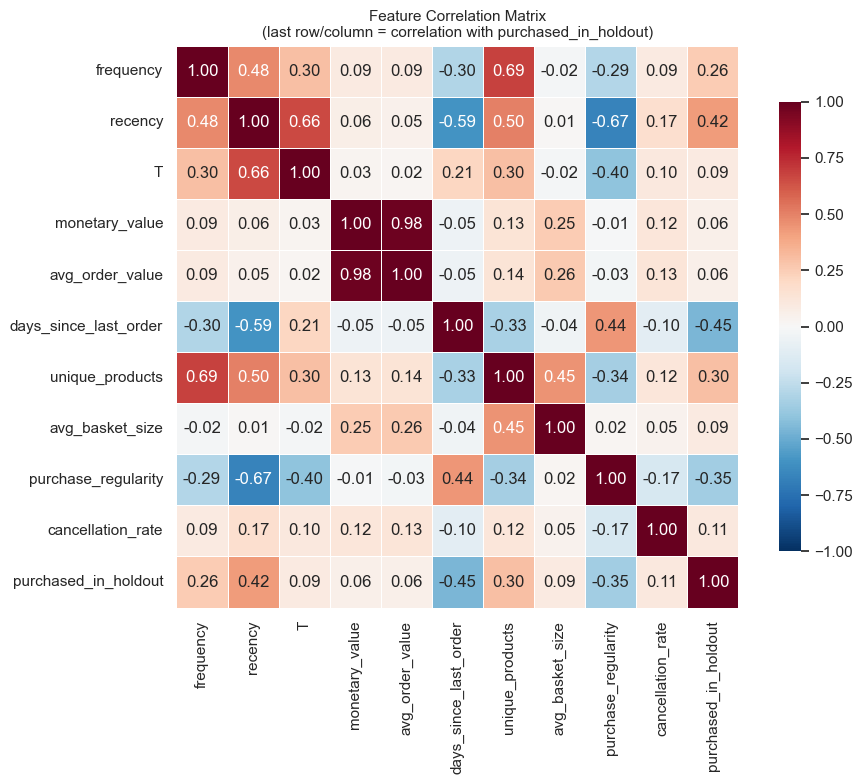

All feature correlations with purchased_in_holdout (sorted):
  days_since_last_order          -0.453
  recency                        +0.424
  purchase_regularity            -0.350
  unique_products                +0.304
  frequency                      +0.255
  cancellation_rate              +0.108
  T                              +0.091
  avg_basket_size                +0.088
  avg_order_value                +0.056
  monetary_value                 +0.055


In [11]:
numeric_features = [
    'frequency', 'recency', 'T', 'monetary_value', 'avg_order_value',
    'days_since_last_order', 'unique_products', 'avg_basket_size',
    'purchase_regularity', 'cancellation_rate', 'purchased_in_holdout',
]
corr = customers[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    ax=ax, vmin=-1, vmax=1,
)
ax.set_title('Feature Correlation Matrix\n(last row/column = correlation with purchased_in_holdout)',
             fontsize=11)
plt.tight_layout()
plt.show()

print("All feature correlations with purchased_in_holdout (sorted):")
target_corr = corr['purchased_in_holdout'].drop('purchased_in_holdout').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    print(f"  {feat:<30} {val:+.3f}")

**Observations:**
- **`days_since_last_order`** is the strongest predictor (r = −0.41) — customers who bought recently are far more likely to buy again. This is the classic RFM "recency" signal.
- **`frequency`** (r = +0.39) and **`recency`** (r = +0.33, BG/NBD tenure) are the next most predictive — longer customer histories correlate with future repurchase.
- **`purchase_regularity`** shows a meaningful negative correlation — irregular buyers are less likely to return. *Caveat: one-time buyers are assigned `purchase_regularity = 999` as a fill value, which partially inflates this correlation since one-time buyers also have lower holdout rates. Interpret cautiously.*
- **`monetary_value`** and **`avg_order_value`** both have modest positive correlations — spending level matters, but less than behavioural signals like recency and frequency

## 8. Key Takeaways & Modeling Rationale

The EDA findings directly inform the two-stage modeling approach used in the next notebooks:

| Finding | Modeling implication |
|---------|---------------------|
| 31% one-time buyers still repurchase | Binary classification first (Stage 1) — don't exclude them |
| `days_since_last_order` is the top predictor (r = −0.41) | RFM features are the right feature set for Stage 1 |
| 52% holdout positive rate — near-balanced classes | No heavy class weighting needed; standard binary cross-entropy works |
| Revenue is highly concentrated (top 20% → 61.3%) | Tier-based segmentation (Stage 2) captures most of the value efficiently |
| Revenue is right-skewed with high variance | Spend tiers are more robust than individual-level regression for revenue estimation |

**Next:** `02_purchase_propensity_model.ipynb` — binary classifier (LightGBM) predicting whether each customer will purchase in the holdout window.

---

## Appendix: Data Dictionary — `clv_data.csv`

### Features (inputs to the model)

| Column | Type | Description |
|---|---|---|
| `user_id` | int | Customer identifier |
| `frequency` | int | Number of repeat purchases (total_orders - 1) |
| `recency` | int | Days between first and last order |
| `T` | int | Customer age in days at calibration end (2011-06-09) |
| `monetary_value` | float | Avg order revenue on repeat transactions; falls back to avg_order_value for one-time buyers |
| `total_orders` | int | Total distinct invoices in calibration period |
| `total_spend` | float | Total calibration spend (£) |
| `avg_order_value` | float | Mean order revenue across all calibration orders |
| `days_since_last_order` | int | Days from last order to calibration end |
| `unique_products` | int | Distinct StockCodes purchased across calibration |
| `avg_basket_size` | float | Mean distinct products per order |
| `purchase_regularity` | float | Std of inter-purchase intervals in days; **999 = one-time buyer** |
| `days_active` | int | Days between first and last order (same as recency) |
| `cancellation_rate` | float | Fraction of orders that were cancellations (computed pre-cleaning) |
| `country` | str | Customer's most frequent country of purchase |

### Holdout labels (validation targets, not model inputs)

| Column | Type | Description |
|---|---|---|
| `actual_holdout_transactions` | int | Distinct invoices in holdout window (2011-06-09 to 2011-12-09) |
| `actual_holdout_revenue` | float | Total revenue in holdout window (£) |
| `purchased_in_holdout` | int | Binary target: 1 if customer made ≥1 holdout purchase |
